In [177]:
import sys
sys.path.append('/Users/chy/imaging/')
import pymethods as pma
from pymethods import pyplot as plt

import pathlib as pt
import numpy as np
from time import time
import matplotlib


In [178]:
%matplotlib inline

In [226]:
from pymethods import parse

path_angio = pt.Path('C:/Users/chy/imaging/pymethods/Datasets/test_1/angiography')
path_oct = pt.Path('C:/Users/chy/imaging/pymethods/Datasets/test_1/oct')

# notice how we use the CenterlinesA to parse the centerlines. This ensures that the centerlines are oriented correctly
folder_angio = pma.parse.angiography.CenterlinesB(path_angio)
folder_oct = pma.parse.ivoct.Folder(path_oct)
try:
    folder_oct.load()
except:
    folder_oct.parse(processors=8)

INFO:root:Extracting Contours and Landmark Data from Images


done


let us first extract the necessary angiography data

## Orienting the centerlines

In [227]:
centerline_main, centerline_bifur = folder_angio.parse().values()

We must note that the CenterlinesA and the CenterlinesB class both contain a parse method which orients the centerlines, bifCenterlines 1 and 2 and centerlines 1 and 2 respectively. We see that the centerlines are now ordered distal to proximal

[[  58.48577499   58.43398863   58.37799811 ...   15.27618827
    15.17668593   15.08923435]
 [-213.6060028  -213.61452256 -213.61104584 ... -154.34966713
  -154.37958509 -154.4161072 ]
 [ 321.9945679   322.08525077  322.17335866 ...  361.84004734
   361.81380009  361.7694092 ]]
[[  65.99797821   65.98887332   65.97993621 ...   55.76291171
    55.74954362   55.73617554]
 [-196.1092987  -196.1068569  -196.1061116  ... -192.97320417
  -192.97261738 -192.9720306 ]
 [ 339.8927612   339.90483018  339.91717511 ...  349.94352971
   349.95089085  349.958252  ]]


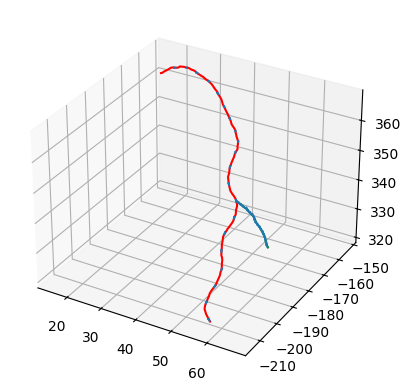

In [228]:
centerline_main.plot3d('r')
main_tangents = centerline_main.transport_frames()[:, :, -1]
print(centerline_main)
print(centerline_bifur)

centerline_bifur.plot3d('g')
transportFrames = centerline_main.transport_frames()

for i, (center, frame) in enumerate(zip(centerline_main.T, transportFrames)):
    if i%50 == 0:
        pma.arrays.ColumnVector(frame[:, -1]).quiver3d(origin=center)
       


transportFrames = centerline_bifur.transport_frames()
for i, (center, frame) in enumerate(zip(centerline_bifur.T, transportFrames)):
    if i%50 == 0:
        pma.arrays.ColumnVector(frame[:, -1]).quiver3d(origin=center)

plt.show()

Support for third party widgets will remain active for the duration of the session. To disable support:

Support for third party widgets will remain active for the duration of the session. To disable support:

## Scaling the OCT Data

To generate our surface we need to know the spacing between each frame and the total pixels per mm per image. This is extracted externally

In [242]:
mm_per_pixel = 0.00943
mm_per_frame = 0.244

We first need to scale our oct data. The ivoct.Folder object has a convenience function which performs the scaling for us and provides us with the data necessary for reconstruction

In [243]:
contours, landmark, frame_id, image_files, landmark_path = folder_oct.data_scaled(mm_per_pixel).values()
print(contours)

[Contour([[5.93569482, 5.93369451, 5.93272294, ..., 5.93798088,
          5.9371236 , 5.93569482],
         [5.52602396, 5.53437688, 5.54408824, ..., 5.51283515,
          5.51898993, 5.52602396],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ]]), Contour([[5.96433652, 5.96734796, 5.96956808, ..., 5.95785641,
          5.96097337, 5.96433652],
         [5.46872737, 5.47488215, 5.48156448, ..., 5.4556089 ,
          5.46266052, 5.46872737],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ]]), Contour([[5.97078145, 5.96999012, 5.97139693, ..., 5.97421054,
          5.97278175, 5.97078145],
         [5.49740864, 5.50692656, 5.51646647, ..., 5.48111166,
          5.48846223, 5.49740864],
         [0.        , 0.        , 0.        , ..., 0.        ,
          0.        , 0.        ]]), Contour([[5.9937036 , 5.99227482, 5.99027451, ..., 5.99484663,
          5.99456088, 5.9937036 ],
         [5.5

# Positioning the contours

Since we are translating the contours from their centroid, to approximate the location of our artery we shall need to know where our landmark is located. We have specified the landmark as the location where the bifurcation centerline is passing through and is shown as a blue spot along the OCT image. We can do so by approximating the point perpendicular to the main centerline which lies on the bifurcation centerline for the distance specified by our landmark

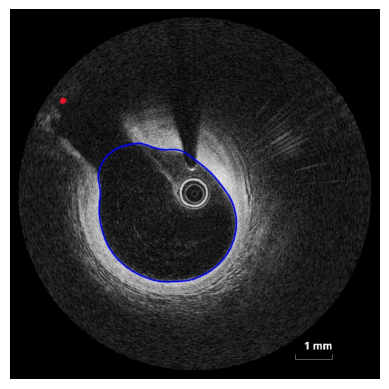

In [244]:
plt.figure()
pma.parse.ivoct.Image(landmark_path).show()
plt.show()

Support for third party widgets will remain active for the duration of the session. To disable support:

The vector which passes from the contour centroid to the landmark is given by landmark. We can obtain this distance from the bar property

In [245]:
print('the landmark vector:\n', landmark)
landmark_hat = pma.math.normalize(landmark).squeeze()
print(' the length of the landmark vector:', landmark.bar)

the landmark vector:
 [[-2.75608252]
 [-3.01971626]
 [ 0.        ]]
 the length of the landmark vector: 4.088358738817633


Every curve has a method which calculates the point pairs at a specified distance between another curves. Bellow we show the output as the dictionary containing the point on the main centerline, the bifurcation centerline, the error and the vector fromt he main to bifur centerlines

In [246]:
perpendicularPointDict = centerline_main.findPointPairsAtPerpendicularDistance(centerline_bifur, distance=landmark.bar, resolution=0.0001)
print("the data required:\n", perpendicularPointDict)

the data required:
 {'on_main': Vector([  56.73895995, -195.28171014,  347.99384953]), 'on_input': Vector([  60.08929825, -193.13070679,  347.05978394]), 'error': 0.0011474307782357585, 'vector': Vector([ 3.3503383 ,  2.15100336, -0.93406559])}


In [247]:
pt_main, pt_bifur, error, vector = perpendicularPointDict.values()

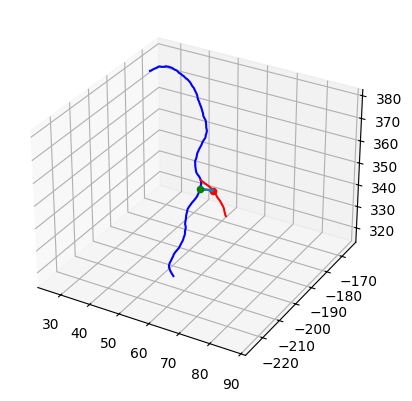

In [248]:
plt.figure_3d()
centerline_main.plot3d('b')
centerline_bifur.plot3d('r')
vector.quiver3d(origin=pt_main)
pt_main.scatter3d(color='green')
pt_bifur.scatter3d(color='red')
plt.equal_aspect_3d_centered(pt_main)
plt.show()

Originally our transport frames are not oriented along the centerline. But since we now have an approximation to of the orientation of our frames we can now orient our transport frames.

[[ 0.81969811]
 [ 0.524852  ]
 [-0.22939687]]
[ 0.26790173 -0.96344624  0.        ]
[[-0.25948803 -0.92295384 -0.28429239]
 [ 0.57731806 -0.38423331  0.72046417]
 [-0.77418978  0.02282469  0.63254187]]
[[-0.96344624  0.26790173  0.        ]
 [-0.26790173 -0.96344624  0.        ]
 [ 0.          0.          1.        ]]
[[-0.73861333  0.67412933  0.        ]
 [-0.67412933 -0.73861333  0.        ]
 [ 0.          0.          1.        ]]
[[-0.91986881 -0.27022065 -0.28429239]
 [-0.01902128 -0.69323125  0.72046417]
 [-0.39176467  0.66814013  0.63254187]]
11.296555450103718


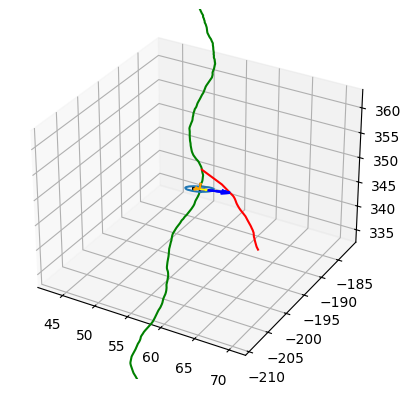

In [249]:
orientedTransportFrames, origin_id = centerline_main.oriented_transport_frames(
    pt_main, vector, landmark_hat
)
mainTransportFrames = centerline_main.transport_frames()
fig, ax=plt.figure_3d()

ax.set_xlim(350,365)
ax.set_ylim(-170,-140)
ax.set_zlim(-30,0)
centerline_main.plot3d('g')
centerline_bifur.plot3d('r')

# the now oriented transport frames
pma.arrays.Basis(orientedTransportFrames[origin_id]).quiver3d(
    origin=centerline_main[:, origin_id], color='orange'
)
ijk_self = pma.arrays.Basis(mainTransportFrames[origin_id])
Vector =  pma.arrays.ColumnVector(vector).hat
projected = Vector.project_to_plane(ijk_self[:, -1])
print(projected)
j_new = pma.math.normalize(
    projected.change_reference_frame(ijk_self)).squeeze()
print(j_new)
z_new = np.array([0, 0, 1])
ijk_new = pma.arrays.Basis(
    pma.math.normalize(pma.math.cross(j_new, z_new)), j_new, z_new
)

i_real = np.array([landmark_hat[1], landmark_hat[0], 0])
j_real = np.array([-landmark_hat[0], landmark_hat[1], 0])
ijk_real = pma.arrays.Basis(i_real, j_real, z_new)
    
newTransportFrame = np.zeros_like(mainTransportFrames[origin_id])
newTransportFrame = pma.arrays.Basis( mainTransportFrames[origin_id] @ ijk_new @ ijk_real)
print( mainTransportFrames[origin_id])
print(ijk_new)
print(ijk_real)
print(newTransportFrame)

# the now original transport frames
pma.arrays.Basis(mainTransportFrames[origin_id]).quiver3d(
    origin=centerline_main[:, origin_id], color='black'
)
vector.quiver3d(
    origin=centerline_main[:, origin_id], color='blue'
)
projected.quiver3d(
    origin=centerline_main[:, origin_id], color='yellow'
)

contour = contours[frame_id]
area = pma.math.area(contour)
print(area)
contour = mainTransportFrames[origin_id] @ (contour - contour.centroid) + centerline_main[:, origin_id, None]

contour.plot3d()

plt.equal_aspect_3d_centered(pt_main)
plt.show()

However this is not yet enough to orient our contours. We still need to ensure that the spacing between the frames is correct. To do so we estimate the fraction along the main centerline our landmark is located

In [250]:
s_location_landmark = centerline_main.s_frac[origin_id]
print(s_location_landmark)

0.3231795922357249


From here we can now approximate the fraction along the artery where the frames are located

In [251]:
frac_per_frame = mm_per_frame/centerline_main.s_tot
print(frac_per_frame)

0.0023297680166998952


Thus we can figure out the required fractions to interpolate our centerline

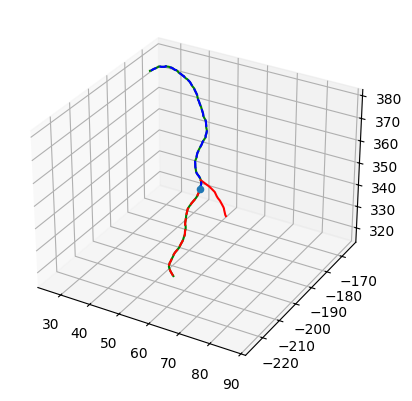

In [252]:
plt.figure_3d()
# calculate the spacing distal to the landmark
distal_half = pma.utils.gap_space(s_location_landmark, 0, frac_per_frame)
# calculate the spacing proximal to the landmark
proximal_half = pma.utils.gap_space(s_location_landmark, 1, frac_per_frame)[:-1]

#for visualiztion purposes
main_centerlin_distal = pma.arrays.Curve(centerline_main(distal_half))
main_centerlin_proximal = pma.arrays.Curve(centerline_main(proximal_half))

centerline_main.plot3d('g')
centerline_bifur.plot3d('r')

main_centerlin_distal.plot3d('r--')
main_centerlin_proximal.plot3d('b--')
centerline_main[:, origin_id].scatter3d()
plt.equal_aspect_3d_centered(pt_main)
plt.show()

We can now calculate the required arc length fraction to obtain the required centerline

In [253]:
s_req = np.concatenate(
        [distal_half, proximal_half[1:]]
)
s_req.sort()
interpolated_centerline = centerline_main(s_req)

interpolated_landmark = len(distal_half)


The portion of the centerline used can now be calculated

In [254]:
centerline_start = interpolated_landmark-frame_id
centerline_end = centerline_start + len(contours)
print(centerline_start)
print(centerline_end, interpolated_centerline.shape[-1])
# we should assert that the centerline start is greater than 0
assert centerline_start > -1
# we should assert that the amount of frames from the landmark is less than the interpolated centerline
assert centerline_end < interpolated_centerline.shape[-1]

130
392 428


[10.931861217909955, 11.425203891701873, 11.392484042722863, 11.228084467881487, 11.252252940959798, 11.071519096524117, 10.835313333902, 10.64085119406936, 10.749541543903108, 11.29171884041148, 11.308322037426326, 11.328787642693829, 11.7606805267348, 11.837391708949156, 11.859154065765097, 11.87225948352318, 12.285067312556318, 12.297217693939995, 12.26705363643708, 12.525624301995148, 12.395589569316956, 12.213589116009803, 12.03242496968467, 12.062554620806585, 11.969786921583328, 11.851608094689809, 11.761943237274991, 11.856675006349187, 11.772465041831401, 11.550814212478226, 11.439730261722524, 11.698552542775051, 11.380841354036209, 11.35705416237414, 11.097611235957327, 11.062513734012105, 11.035216168126189, 10.905860332004718, 10.561074785575627, 10.68396875636341, 10.35469417666692, 10.185996316740917, 9.887831681934575, 10.171160071858166, 10.388451753513852, 10.273069780745459, 10.123944814380621, 10.156023630908399, 10.15102608119168, 10.146227009282685, 10.14180584779

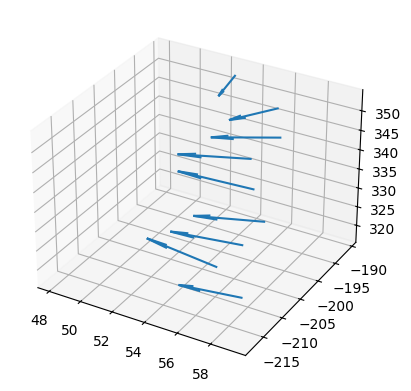

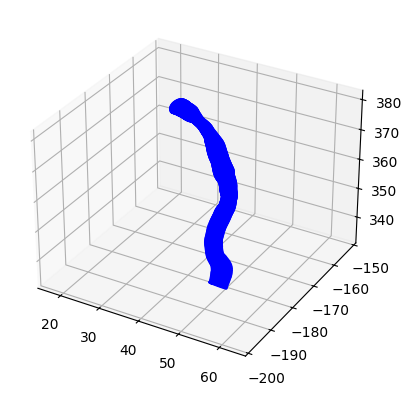

In [255]:
transportFrames, origin_id = interpolated_centerline.oriented_transport_frames(interpolated_centerline[:, interpolated_landmark, None], vector, landmark_hat)
translated_contours = []

for i, (center, frame) in enumerate(zip(centerline_main.T, transportFrames)):
    if i%50 == 0:
        pma.arrays.ColumnVector(frame[:, 0]*5).quiver3d(origin=center)

area_array = []
for j, i in enumerate(range(centerline_start, centerline_end)):
    contour = contours[j]
    contour = pma.math.make_3d(contour)
    window_size = pma.utils.make_odd(
        contour.shape[-1]//100)
    contour = pma.arrays.Contour(contour).filter(window_size, 3)
    contour = contour(np.linspace(0, 1, 100))
    contour = contour - contour.centroid
    origin = interpolated_centerline[:, i].make_column()
    basis = transportFrames[i]
    contour =  (basis @ contour) + origin
    translated_contours.append(contour)
    area_array.append(pma.math.area(contour))

print(area_array)
surface = pma.arrays.structured.CylindricalSurface.from_contours(translated_contours)
surface.interpolate_long(300)
surface = surface.filter(window_size=15)
surface = surface.interpolate_contours(100)
plt.figure_3d()
surface.plot3d()
plt.equal_aspect_3d()
plt.show()


# High Level API

In [256]:
surface.to_stl(r'../mesh_F252.stl')